### Load Dependencies

In [30]:
import pandas as pd
import pickle
from sklearn.preprocessing import OneHotEncoder

### Load CSV

In [31]:
df = pd.read_csv("data/city_day.csv")
df.head(5)
df.isnull().sum()

City              0
Date              0
PM2.5          4289
PM10          10766
NO             3233
NO2            3217
NOx            4043
NH3            9847
CO             1961
SO2            3544
O3             3660
Benzene        5287
Toluene        7555
Xylene        16807
AQI            4282
AQI_Bucket     4282
dtype: int64

### Information of Data

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26219 entries, 0 to 26218
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        26219 non-null  object 
 1   Date        26219 non-null  object 
 2   PM2.5       21930 non-null  float64
 3   PM10        15453 non-null  float64
 4   NO          22986 non-null  float64
 5   NO2         23002 non-null  float64
 6   NOx         22176 non-null  float64
 7   NH3         16372 non-null  float64
 8   CO          24258 non-null  float64
 9   SO2         22675 non-null  float64
 10  O3          22559 non-null  float64
 11  Benzene     20932 non-null  float64
 12  Toluene     18664 non-null  float64
 13  Xylene      9412 non-null   float64
 14  AQI         21937 non-null  float64
 15  AQI_Bucket  21937 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.2+ MB


In [33]:
df.head(5)

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [34]:
column_types = df.dtypes
print("\nData Types:\n", column_types)


Data Types:
 City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object


In [35]:
print(df['City'])

0                 Ahmedabad
1                 Ahmedabad
2                 Ahmedabad
3                 Ahmedabad
4                 Ahmedabad
                ...        
26214    Thiruvananthapuram
26215    Thiruvananthapuram
26216    Thiruvananthapuram
26217    Thiruvananthapuram
26218    Thiruvananthapuram
Name: City, Length: 26219, dtype: object


### Check null values

In [36]:
df.isnull().sum()

City              0
Date              0
PM2.5          4289
PM10          10766
NO             3233
NO2            3217
NOx            4043
NH3            9847
CO             1961
SO2            3544
O3             3660
Benzene        5287
Toluene        7555
Xylene        16807
AQI            4282
AQI_Bucket     4282
dtype: int64

In [37]:
def fillna_with_mean(df):
    """fill the NaN values with the coloumn mean value"""
    exe_col = ['City', 'Date', 'AQI_Bucket']
    num_col = df.select_dtypes(include=['int64', 'float64']).columns
    num_col = [col for col in num_col if col not in exe_col]
    for col in num_col:
        mean = df[col].mean()
        df[col] = df[col].fillna(mean)
    return df

In [38]:
df = fillna_with_mean(df)

### Create Feature Set

In [39]:
x1 = df.iloc[:,:14].values
x1.shape

(26219, 14)

In [40]:
x1[0]

array(['Ahmedabad', '2015-01-01', 71.82890743274054, 125.49238012036498,
       0.92, 18.22, 17.15, 25.336162350354265, 0.92, 27.64, 133.36, 0.0,
       0.02, 0.0], dtype=object)

In [41]:
y1 = df.iloc[:,14:15].values
y1.shape

(26219, 1)

In [42]:
z1 = pd.DataFrame(x1, columns=df.columns[:14])
z1.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene
0,Ahmedabad,2015-01-01,71.828907,125.49238,0.92,18.22,17.15,25.336162,0.92,27.64,133.36,0.0,0.02,0.0
1,Ahmedabad,2015-01-02,71.828907,125.49238,0.97,15.69,16.46,25.336162,0.97,24.55,34.06,3.68,5.5,3.77
2,Ahmedabad,2015-01-03,71.828907,125.49238,17.4,19.3,29.7,25.336162,17.4,29.07,30.7,6.8,16.4,2.25
3,Ahmedabad,2015-01-04,71.828907,125.49238,1.7,18.48,17.97,25.336162,1.7,18.59,36.08,4.43,10.14,1.0
4,Ahmedabad,2015-01-05,71.828907,125.49238,22.1,21.42,37.76,25.336162,22.1,39.33,39.31,7.01,18.89,2.78


In [43]:
# drop date colume
z1=z1.drop(["Date"], axis=1)

In [44]:
z1.head()

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene
0,Ahmedabad,71.828907,125.49238,0.92,18.22,17.15,25.336162,0.92,27.64,133.36,0.0,0.02,0.0
1,Ahmedabad,71.828907,125.49238,0.97,15.69,16.46,25.336162,0.97,24.55,34.06,3.68,5.5,3.77
2,Ahmedabad,71.828907,125.49238,17.4,19.3,29.7,25.336162,17.4,29.07,30.7,6.8,16.4,2.25
3,Ahmedabad,71.828907,125.49238,1.7,18.48,17.97,25.336162,1.7,18.59,36.08,4.43,10.14,1.0
4,Ahmedabad,71.828907,125.49238,22.1,21.42,37.76,25.336162,22.1,39.33,39.31,7.01,18.89,2.78


In [45]:
x1 = z1.iloc[:,0:13].values
z1 = pd.DataFrame(x1)

In [46]:
z1.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,Ahmedabad,71.828907,125.49238,0.92,18.22,17.15,25.336162,0.92,27.64,133.36,0.0,0.02,0.0
1,Ahmedabad,71.828907,125.49238,0.97,15.69,16.46,25.336162,0.97,24.55,34.06,3.68,5.5,3.77
2,Ahmedabad,71.828907,125.49238,17.4,19.3,29.7,25.336162,17.4,29.07,30.7,6.8,16.4,2.25
3,Ahmedabad,71.828907,125.49238,1.7,18.48,17.97,25.336162,1.7,18.59,36.08,4.43,10.14,1.0
4,Ahmedabad,71.828907,125.49238,22.1,21.42,37.76,25.336162,22.1,39.33,39.31,7.01,18.89,2.78


In [47]:
z1[0].nunique()

24

### Final Feature Set

In [48]:
ohe = OneHotEncoder(drop='first')
x_new1 = pd.DataFrame(ohe.fit_transform(x1[:,[0]]).toarray()) #state
feature_set = pd.concat([x_new1,pd.DataFrame(z1.iloc[:,1:].values)],axis=1,sort=False)

In [49]:
ohe.transform([["Ahmedabad"]])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 0 stored elements and shape (1, 23)>

In [50]:
pickle.dump(ohe,open("Models/OneHotEncoder_Featureset.pkl","wb"))

In [51]:
feature_set

,0,1,2,3,4,5,6,7,8,9,...,2,3,4,5,6,7,8,9,10,11
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.92,18.22,17.15,25.336162,0.92,27.64,133.36,0.0,0.02,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.97,15.69,16.46,25.336162,0.97,24.55,34.06,3.68,5.5,3.77
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,17.4,19.3,29.7,25.336162,17.4,29.07,30.7,6.8,16.4,2.25
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.7,18.48,17.97,25.336162,1.7,18.59,36.08,4.43,10.14,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,22.1,21.42,37.76,25.336162,22.1,39.33,39.31,7.01,18.89,2.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26214,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.6,8.98,12.48,5.65,0.49,5.5,42.41,3.300132,9.029794,3.155895
26215,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.27,10.01,13.8,5.73,0.44,5.62,44.55,3.300132,9.029794,3.155895
26216,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.17,9.67,13.35,5.93,0.51,5.52,38.97,3.300132,9.029794,3.155895
26217,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.28,9.52,13.56,5.84,0.46,5.32,39.23,3.300132,9.029794,3.155895


### Model Training

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

In [53]:
x_train,x_test,y_train,y_test = train_test_split(feature_set,y1,test_size=0.25,random_state=0)

In [54]:

# multiple linear regression model
mreg = LinearRegression()
mreg.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [55]:
y_predict = mreg.predict(x_test)

In [98]:
mreg.score(x_test, y_test)*100

78.74472669329278

### df2 = pd.DataFrame({'Actual': y_test, 'Predicted':y_predict}) 

In [57]:
print (df) 
from matplotlib import pyplot as plt
#Visualize the best fit line
#df['Date'] = pd.to_datetime(df['Date'])
#df['year'] = df['Date'].dt.year
#year=df['year']

                     City        Date      PM2.5       PM10     NO    NO2  \
0               Ahmedabad  2015-01-01  71.828907  125.49238   0.92  18.22   
1               Ahmedabad  2015-01-02  71.828907  125.49238   0.97  15.69   
2               Ahmedabad  2015-01-03  71.828907  125.49238  17.40  19.30   
3               Ahmedabad  2015-01-04  71.828907  125.49238   1.70  18.48   
4               Ahmedabad  2015-01-05  71.828907  125.49238  22.10  21.42   
...                   ...         ...        ...        ...    ...    ...   
26214  Thiruvananthapuram  2020-04-27  14.130000   34.27000   5.60   8.98   
26215  Thiruvananthapuram  2020-04-28  23.840000   44.32000   6.27  10.01   
26216  Thiruvananthapuram  2020-04-29  18.540000   34.48000   6.17   9.67   
26217  Thiruvananthapuram  2020-04-30  20.570000   48.19000   6.28   9.52   
26218  Thiruvananthapuram  2020-05-01  17.580000   37.49000   2.56   7.84   

         NOx        NH3     CO    SO2      O3   Benzene    Toluene    Xylen

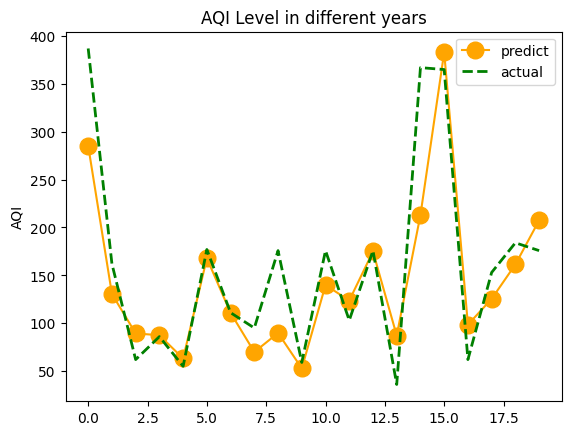

In [58]:
plt.plot(y_predict[:20],color ='orange', marker ='o', markersize = 12, label ='predict')
plt.plot(y_test[:20],color ='g', linestyle ='dashed', linewidth = 2, label ='actual')
plt.title('AQI Level in different years') 
plt.ylabel('AQI')
plt.legend() 
plt.show()

### polynomial regression model
### degree = 2

In [59]:
# make sure you test polynomial regression, first transform the data with 2 degree.
poly_reg = PolynomialFeatures(degree = 2)
preg = LinearRegression()
pf = poly_reg.fit_transform(x_train)
preg.fit(pf,y_train)

pr_y_predict = preg.predict(poly_reg.fit_transform(x_test))

In [99]:
preg.score(poly_reg.fit_transform(x_test), y_test)*100

82.12114661875106

In [61]:
pickle.dump(poly_reg, open("Models/ploy_reg.pkl",'wb'))

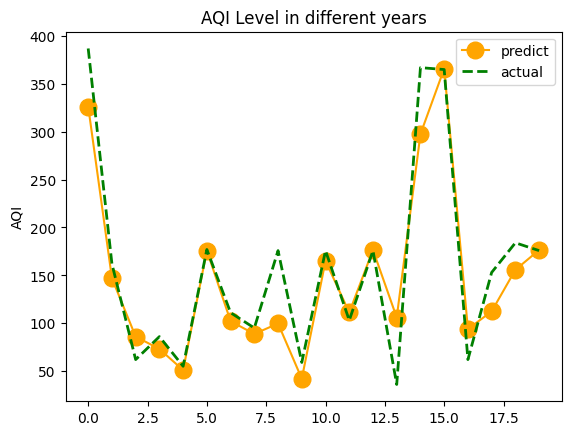

In [62]:
plt.plot(pr_y_predict[:20],color ='orange', marker ='o', markersize = 12, label ='predict')
plt.plot(y_test[:20],color ='g', linestyle ='dashed', linewidth = 2, label ='actual')
plt.title('AQI Level in different years') 
plt.ylabel('AQI')
plt.legend() 
plt.show()

# Decision tree regression model

In [63]:
dec_tree = DecisionTreeRegressor(random_state = 0)
dec_tree.fit(x_train,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_le

In [64]:
dt_y_predict = dec_tree.predict(x_test)

In [100]:
dec_tree.score(x_test, y_test)*100

76.64504705570099

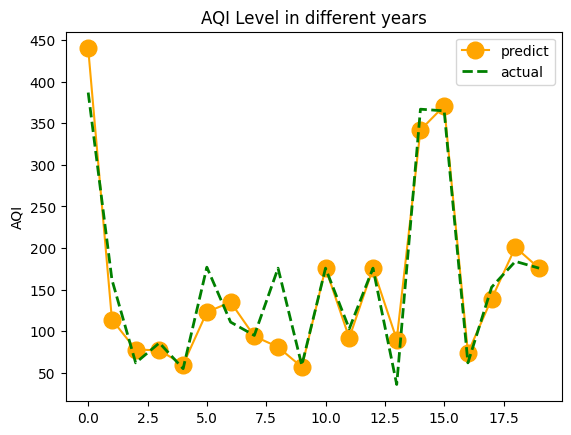

In [66]:
plt.plot(dt_y_predict[:20],color ='orange', marker ='o', markersize = 12,  label ='predict')
plt.plot(y_test[:20],color ='g', linestyle ='dashed', linewidth = 2, label ='actual')
plt.title('AQI Level in different years') 
plt.ylabel('AQI')
plt.legend() 
plt.show()

# random forest regression model

In [67]:
from sklearn.ensemble import RandomForestRegressor

# Reshape the target variable y_train and y_test
y_train_reshaped = y_train.ravel()
y_test_reshaped = y_test.ravel()

# Create and train the Random Forest Regressor
rt_reg = RandomForestRegressor(n_estimators=500, random_state=0)
rt_reg.fit(x_train, y_train_reshaped)

# Make predictions
rt_y_predict = rt_reg.predict(x_test)


In [68]:
rt_reg = RandomForestRegressor(n_estimators = 500, random_state = 0)
rt_reg.fit(x_train,y_train)
rt_y_predict = rt_reg.predict(x_test)

c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [101]:
rt_reg.score(x_test, y_test)*100

85.80079620332299

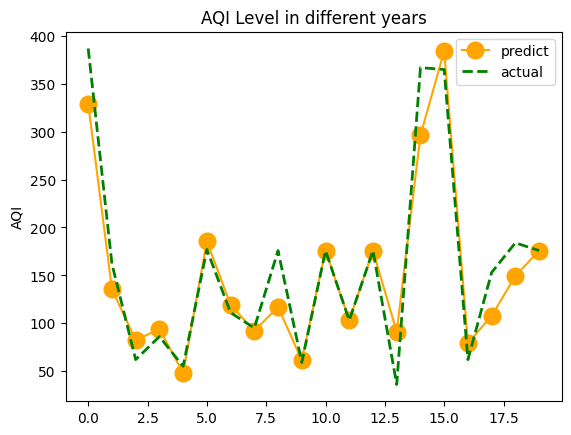

In [70]:
plt.plot(rt_y_predict[:20],color ='orange', marker ='o', markersize = 12, label ='predict')
plt.plot(y_test[:20],color ='g', linestyle ='dashed', linewidth = 2, label ='actual')
plt.title('AQI Level in different years') 
plt.ylabel('AQI')
plt.legend() 
plt.show()

In [71]:
# --- feature scaling the paramenters for better results ---

In [72]:
from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()
sc_y = StandardScaler()
x_train_svr = sc_x.fit_transform(x_train)
# y_train_svr = sc_y.fit_transform(y_train)

In [73]:
pickle.dump(sc_x, open("Models/Standard_Scaler_X_SVR.pkl",'wb'))

In [74]:
svr_reg = SVR()
svr_reg.fit(x_train_svr,y_train)

c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [75]:
x_test.shape

(6555, 35)

In [76]:
sc_x.transform(x_test).shape

(6555, 35)

In [77]:
svr_y_predict = svr_reg.predict(sc_x.transform(x_test))

In [102]:
svr_reg.score(sc_x.transform(x_test), y_test)*100

56.93260244770397

In [104]:
# svr_y_predict = sc_y.inverse_transform(svr_reg.predict(sc_x.transform(x_test))) 

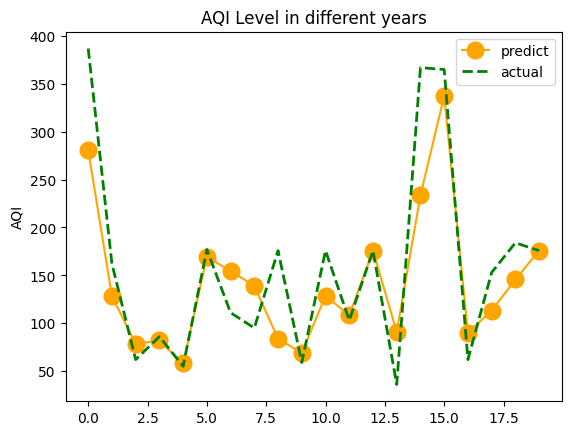

In [80]:
plt.plot(svr_y_predict[:20],color ='orange', marker ='o', markersize = 12,  label ='predict')
plt.plot(y_test[:20],color ='g', linestyle ='dashed', linewidth = 2, label ='actual')
plt.title('AQI Level in different years') 
plt.ylabel('AQI')
plt.legend() 
plt.show()

# Use the loaded pickled model to make predictions 

In [81]:
import pickle

In [82]:
pickle.dump(mreg, open("Models/Multiple_Regression2.pkl",'wb'))
pickle.dump(preg, open("Models/pregression2.pkl",'wb'))
pickle.dump(dec_tree, open("Models/Decision_tree.pkl",'wb'))
pickle.dump(rt_reg, open("Models/RandomForest2.pkl",'wb'))
pickle.dump(svr_reg, open("Models/svrression2.pkl",'wb'))

### Load Pickle Model

In [95]:
with open("Models/pregression2.pkl",'rb') as model:
    pregression = pickle.load(model)

In [96]:
# Load model from file
# pregression.predict(x_test) 
pregression.predict(poly_reg.fit_transform(x_test))

array([[326.35427391],
       [146.89859496],
       [ 86.03682319],
       ...,
       [ 95.14420369],
       [162.34385811],
       [ 49.26893257]], shape=(6555, 1))

In [105]:
pregression.score(poly_reg.fit_transform(x_test), y_test)*100

82.12114661875106